In [2]:
# Environmental Data Analysis - AQI Dataset
# End-to-End Data Analysis Notebook

"""
Project: Environmental Data Analysis
Dataset: daily_aqi_by_cbsa_2025.csv
Objective: Analyze AQI trends, pollution patterns, and environmental insights
Author: Your Name
"""

'\nProject: Environmental Data Analysis\nDataset: daily_aqi_by_cbsa_2025.csv\nObjective: Analyze AQI trends, pollution patterns, and environmental insights\nAuthor: Your Name\n'

In [3]:
# !pip install pandas numpy matplotlib seaborn plotly

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

import os
os.getcwd()

plt.style.use("ggplot")
sns.set()

In [5]:
data_path = "C:/Users/DELL/environmental_analysis/data/daily_aqi_by_cbsa_2025.csv"

df = pd.read_csv(data_path)

df.head()

,CBSA,CBSA Code,Date,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting
0,"Aberdeen, SD",10100,2025-01-01,38,Good,PM2.5,46-013-0004,1
1,"Aberdeen, SD",10100,2025-01-02,32,Good,PM2.5,46-013-0004,1
2,"Aberdeen, SD",10100,2025-01-03,28,Good,PM2.5,46-013-0004,1
3,"Aberdeen, SD",10100,2025-01-04,39,Good,PM2.5,46-013-0004,1
4,"Aberdeen, SD",10100,2025-01-05,25,Good,PM2.5,46-013-0004,1


In [6]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (113899, 8)

Columns:
Index(['CBSA', 'CBSA Code', 'Date', 'AQI', 'Category', 'Defining Parameter',
       'Defining Site', 'Number of Sites Reporting'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113899 entries, 0 to 113898
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   CBSA                       113899 non-null  object
 1   CBSA Code                  113899 non-null  int64 
 2   Date                       113899 non-null  object
 3   AQI                        113899 non-null  int64 
 4   Category                   113899 non-null  object
 5   Defining Parameter         113899 non-null  object
 6   Defining Site              113899 non-null  object
 7   Number of Sites Reporting  113899 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 7.0+ MB

Missing Values:
CBSA                         0
CBSA Code                    0
D

In [7]:
df.describe()

,CBSA Code,AQI,Number of Sites Reporting
count,113899.000000,113899.000000,113899.000000
mean,29862.767540,44.213391,3.252355
std,11425.861483,22.509017,4.714245
min,10100.000000,0.000000,1.000000
25%,19780.000000,33.000000,1.000000
50%,29620.000000,43.000000,2.000000
75%,39900.000000,53.000000,3.000000
max,49740.000000,2122.000000,45.000000


In [8]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.head()

,cbsa,cbsa_code,date,aqi,category,defining_parameter,defining_site,number_of_sites_reporting
0,"Aberdeen, SD",10100,2025-01-01,38,Good,PM2.5,46-013-0004,1
1,"Aberdeen, SD",10100,2025-01-02,32,Good,PM2.5,46-013-0004,1
2,"Aberdeen, SD",10100,2025-01-03,28,Good,PM2.5,46-013-0004,1
3,"Aberdeen, SD",10100,2025-01-04,39,Good,PM2.5,46-013-0004,1
4,"Aberdeen, SD",10100,2025-01-05,25,Good,PM2.5,46-013-0004,1


In [9]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df.head()

,cbsa,cbsa_code,date,aqi,category,defining_parameter,defining_site,number_of_sites_reporting,year,month,day
0,"Aberdeen, SD",10100,2025-01-01,38,Good,PM2.5,46-013-0004,1,2025,1,1
1,"Aberdeen, SD",10100,2025-01-02,32,Good,PM2.5,46-013-0004,1,2025,1,2
2,"Aberdeen, SD",10100,2025-01-03,28,Good,PM2.5,46-013-0004,1,2025,1,3
3,"Aberdeen, SD",10100,2025-01-04,39,Good,PM2.5,46-013-0004,1,2025,1,4
4,"Aberdeen, SD",10100,2025-01-05,25,Good,PM2.5,46-013-0004,1,2025,1,5


In [10]:
df = df.dropna()

print("After cleaning:", df.shape)

After cleaning: (113899, 11)


In [11]:
df = df.drop_duplicates()

print("Duplicates removed")

Duplicates removed


In [12]:
def aqi_category(aqi):
    
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df["aqi_category"] = df["aqi"].apply(aqi_category)

df.head()

,cbsa,cbsa_code,date,aqi,category,defining_parameter,defining_site,number_of_sites_reporting,year,month,day,aqi_category
0,"Aberdeen, SD",10100,2025-01-01,38,Good,PM2.5,46-013-0004,1,2025,1,1,Good
1,"Aberdeen, SD",10100,2025-01-02,32,Good,PM2.5,46-013-0004,1,2025,1,2,Good
2,"Aberdeen, SD",10100,2025-01-03,28,Good,PM2.5,46-013-0004,1,2025,1,3,Good
3,"Aberdeen, SD",10100,2025-01-04,39,Good,PM2.5,46-013-0004,1,2025,1,4,Good
4,"Aberdeen, SD",10100,2025-01-05,25,Good,PM2.5,46-013-0004,1,2025,1,5,Good


In [13]:
df.to_csv("C:/Users/DELL/environmental_analysis/data/cleaned_aqi_data.csv", index=False)

print("Cleaned data saved")

Cleaned data saved


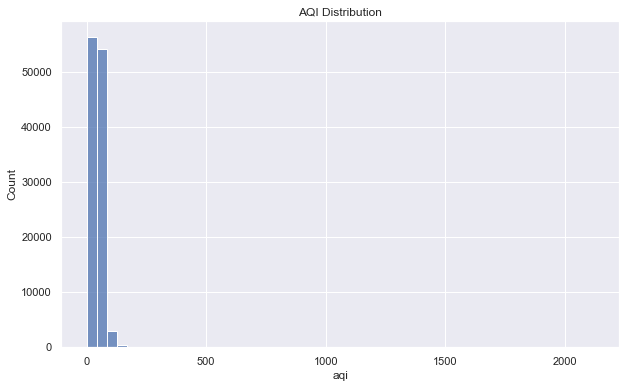

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['aqi'], bins=50)
plt.title("AQI Distribution")
plt.show()

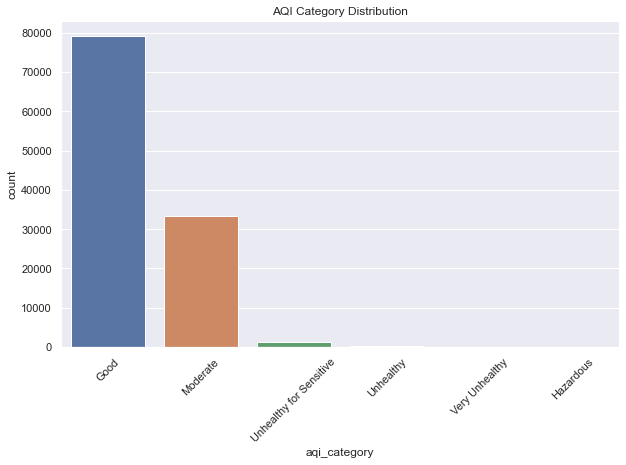

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x="aqi_category", data=df)
plt.xticks(rotation=45)
plt.title("AQI Category Distribution")
plt.show()

In [16]:
top_cities = df.groupby("cbsa")["aqi"].mean().sort_values(ascending=False).head(10)

top_cities

cbsa
El Paso, TX                             119.647541
Riverside-San Bernardino-Ontario, CA    104.540146
Los Angeles-Long Beach-Anaheim, CA       88.941606
Las Cruces, NM                           88.047619
Phoenix-Mesa-Scottsdale, AZ              86.203947
Houston-The Woodlands-Sugar Land, TX     71.686131
El Centro, CA                            71.068493
Las Vegas-Henderson-Paradise, NV         68.332117
Bakersfield, CA                          66.787546
Visalia-Porterville, CA                  66.452586
Name: aqi, dtype: float64

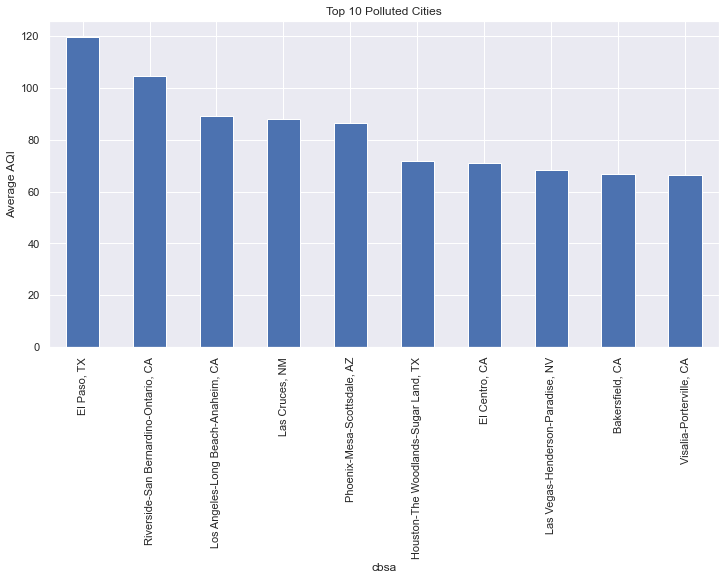

In [17]:
top_cities.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Polluted Cities")
plt.ylabel("Average AQI")
plt.show()

In [18]:
monthly_aqi = df.groupby("month")["aqi"].mean()

monthly_aqi

month
1     40.978505
2     40.971256
3     43.528654
4     45.271854
5     43.850058
6     49.473020
7     47.204455
8     44.847307
9     44.611792
10    31.824280
11    19.761905
Name: aqi, dtype: float64

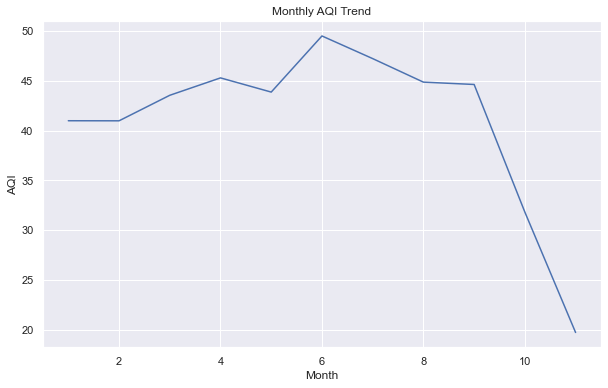

In [19]:
plt.figure(figsize=(10,6))

monthly_aqi.plot()

plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

In [20]:
fig = px.line(monthly_aqi, 
              title="Monthly AQI Trend",
              labels={"value":"AQI","month":"Month"})

fig.show()

In [33]:
location_aqi = df.groupby("cbsa")["aqi"].mean()

location_aqi

cbsa
Aberdeen, SD                         28.578652
Aberdeen, WA                         22.625514
Adrian, MI                           42.092105
Akron, OH                            48.598684
Albany, GA                           47.481481
                                       ...    
Yakima, WA                           34.938272
York-Hanover, PA                     38.903915
Youngstown-Warren-Boardman, OH-PA    50.753289
Yuba City, CA                        48.750000
Yuma, AZ                             53.794872
Name: aqi, Length: 496, dtype: float64

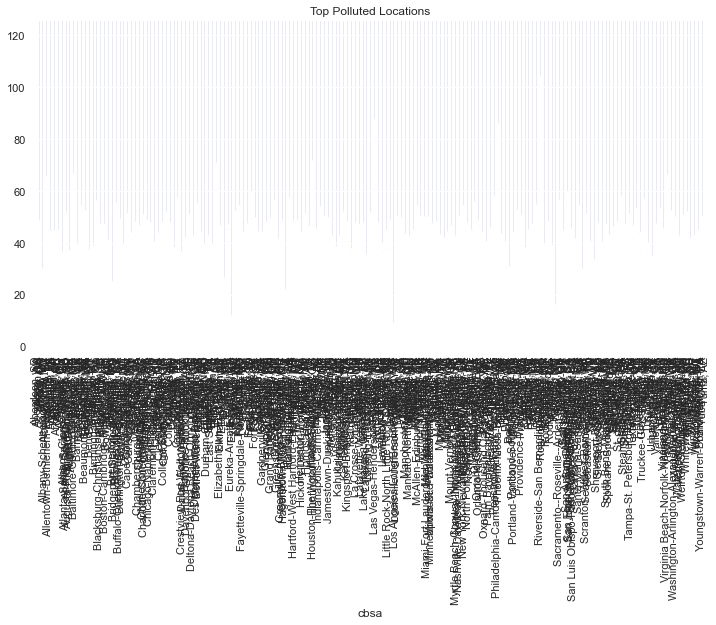

In [34]:
plt.figure(figsize=(12,6))

state_aqi.plot(kind="bar")

plt.title("Top Polluted Locations")
plt.show()

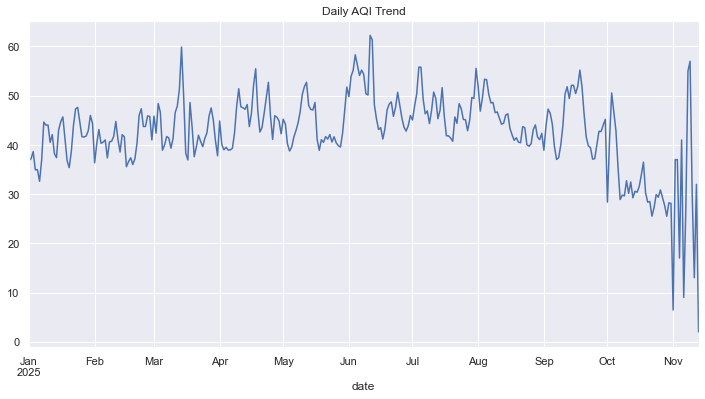

In [24]:
daily_trend = df.groupby("date")["aqi"].mean()

plt.figure(figsize=(12,6))
daily_trend.plot()

plt.title("Daily AQI Trend")
plt.show()

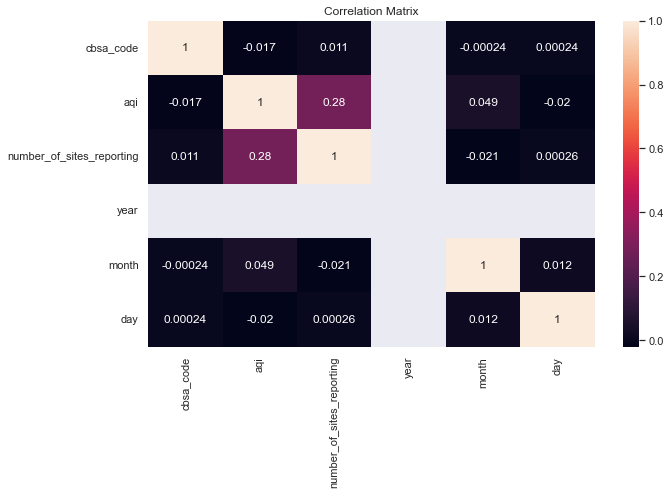

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

In [26]:
fig = px.bar(top_cities,
             title="Top Polluted Cities",
             labels={"value":"AQI","cbsa_name":"City"})

fig.show()

In [27]:
print("Key Insights")

print("1. AQI distribution shows pollution levels across cities")
print("2. Some cities have consistently high AQI")
print("3. Monthly AQI trend shows seasonal variation")
print("4. Certain states have higher pollution levels")
print("5. AQI categories highlight environmental risk levels")

Key Insights
1. AQI distribution shows pollution levels across cities
2. Some cities have consistently high AQI
3. Monthly AQI trend shows seasonal variation
4. Certain states have higher pollution levels
5. AQI categories highlight environmental risk levels


In [28]:
print("Environmental Impact")

print("High AQI leads to health issues")
print("Cities with high AQI need policy intervention")
print("Seasonal AQI increase indicates industrial or weather effects")
print("Government can use this data for pollution control strategies")

Environmental Impact
High AQI leads to health issues
Cities with high AQI need policy intervention
Seasonal AQI increase indicates industrial or weather effects
Government can use this data for pollution control strategies


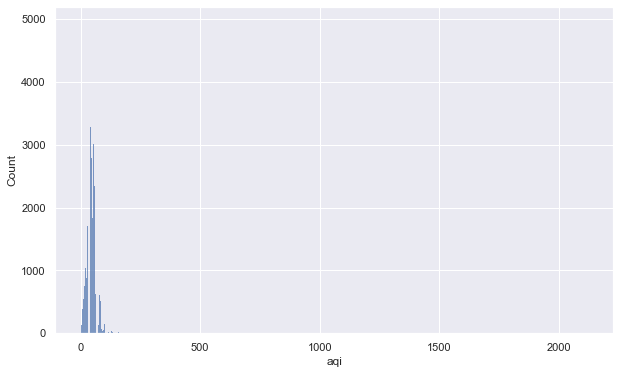

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(df['aqi'])
plt.savefig("C:/Users/DELL/environmental_analysis/reports/aqi_distribution.png")

In [30]:
print("Project Completed")

print("""
This environmental analysis project provides:

Clean AQI dataset
Pollution trend analysis
City and state comparison
Monthly AQI trends
Interactive visualizations
Environmental insights

Ready for dashboard and Streamlit integration
""")

Project Completed

This environmental analysis project provides:

Clean AQI dataset
Pollution trend analysis
City and state comparison
Monthly AQI trends
Interactive visualizations
Environmental insights

Ready for dashboard and Streamlit integration

